## Preprocessing Part

In [1]:
# Preprocessing = Converting the data into a clean, numerical, machine-learning-ready format 
# So models like Linear Regression, Random Forest, and XGBoost can learn from it effectively.

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [3]:
df = pd.read_csv(f"E:\AirPulse AI\Files\data\globalAirQuality.csv")

In [4]:
df.head()

,timestamp,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed
0,2025-11-04 18:25:17.554219,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725
1,2025-11-04 19:25:17.554219,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969
2,2025-11-04 20:25:17.554219,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650
3,2025-11-04 21:25:17.554219,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956
4,2025-11-04 22:25:17.554219,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017


# Convert Timestamp

In [5]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

In [6]:
df['hour'] = df['timestamp'].dt.hour
df['day'] = df['timestamp'].dt.day
df['month'] = df['timestamp'].dt.month

# Dropping Unnecessary Columns

In [7]:
df.drop('timestamp', axis=1, inplace=True) # because we already extracted useful time features

# Checking Missing Values Again

In [8]:
df.isnull().sum()

country        0
city           0
latitude       0
longitude      0
pm25           0
pm10           0
no2            0
so2            0
o3             0
co             0
aqi            0
temperature    0
humidity       0
wind_speed     0
hour           0
day            0
month          0
dtype: int64

<Axes: >

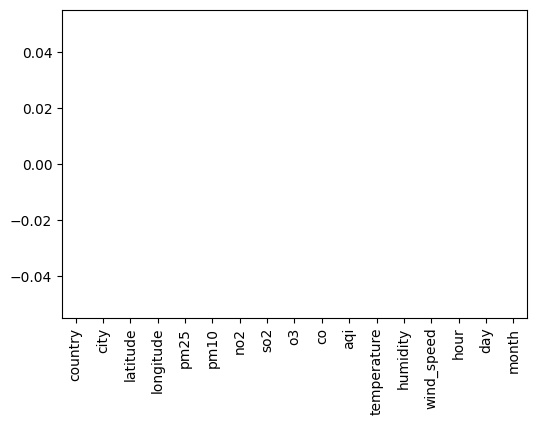

In [9]:
df.isnull().sum().plot(kind="bar", figsize=(6,4)) # Would show zero missing values

# Handling Categorical Features and Encode Categorical Columns

In [10]:
df.head()

,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed,hour,day,month
0,US,New York,40.713,-74.006,50.295,108.938,27.998,6.539,52.568,1.096,108,18.504,70.168,3.725,18,4,11
1,US,New York,40.713,-74.006,32.083,63.043,36.120,4.021,43.536,1.075,90,5.838,80.088,8.969,19,4,11
2,US,New York,40.713,-74.006,42.250,82.553,26.935,9.538,23.320,0.977,84,31.833,62.783,9.650,20,4,11
3,US,New York,40.713,-74.006,30.403,79.951,63.536,7.609,31.369,0.230,158,23.140,89.153,8.956,21,4,11
4,US,New York,40.713,-74.006,21.083,66.423,38.997,6.919,45.615,1.085,97,13.632,76.499,4.017,22,4,11


In [11]:
df.select_dtypes(include='object').columns

Index(['country', 'city'], dtype='object')

In [12]:
le_country = LabelEncoder()
le_city = LabelEncoder()

df['country'] = le_country.fit_transform(df['country'])
df['city'] = le_city.fit_transform(df['city'])

# Creating AQI Categories

In [13]:
def categorize_aqi(aqi):

    if aqi <= 50:
        return 0

    elif aqi <= 100:
        return 1

    elif aqi <= 150:
        return 2

    else:
        return 3

In [14]:
df['aqi_category'] = df['aqi'].apply(categorize_aqi)

# Outlier Analysis

In [15]:
df.describe()

,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,aqi,temperature,humidity,wind_speed,hour,day,month,aqi_category
count,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.000000,18000.0,18000.000000
mean,18.660000,24.500000,23.065980,37.655560,40.369131,70.152228,32.055176,6.035508,48.065100,0.800595,104.645556,21.510251,57.714351,5.283910,11.500000,11.750000,11.0,1.577611
std,11.265498,14.431271,26.156536,78.600701,17.647450,24.999440,13.820680,2.454790,14.950849,0.250254,25.616070,9.509444,18.844908,2.741712,6.922379,4.342259,0.0,0.597585
min,0.000000,0.000000,-37.814000,-123.121000,0.025000,0.061000,0.013000,0.003000,0.114000,0.000000,16.000000,5.000000,25.002000,0.500000,0.000000,4.000000,11.0,0.000000
25%,9.000000,12.000000,12.972000,2.352000,27.904500,53.125500,22.362500,4.360750,38.028500,0.633000,87.000000,13.357750,41.320000,2.937000,5.750000,8.000000,11.0,1.000000
50%,17.500000,24.500000,29.232000,42.146000,40.286500,69.961000,32.019500,6.026000,48.142000,0.800500,103.000000,21.455500,57.847000,5.297000,11.500000,12.000000,11.0,2.000000
75%,29.000000,37.000000,41.008000,103.820000,52.436250,87.256500,41.364250,7.715250,58.258500,0.969000,121.000000,29.688250,74.234750,7.662000,17.250000,15.250000,11.0,2.000000
max,37.000000,49.000000,60.170000,174.763000,115.683000,161.810000,90.019000,16.559000,103.016000,1.832000,231.000000,37.998000,89.997000,9.999000,23.000000,19.000000,11.0,3.000000


# Feature Selection

In [16]:
y = df['aqi']

In [17]:
X = df.drop(['aqi','aqi_category'], axis=1)

# Feature Scaling

In [18]:
# Very important for: Linear Regression and LSTM

In [19]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Save Processed Data

In [20]:
processed_df = pd.DataFrame(
    X_scaled,
    columns=X.columns
)

processed_df['aqi'] = y

In [21]:
processed_df.to_csv(
    "../data/processed_air_quality.csv",
    index=False
)

In [ ]:
processed_df.head()

,country,city,latitude,longitude,pm25,pm10,no2,so2,o3,co,temperature,humidity,wind_speed,hour,day,month,aqi
0,1.450487,0.519719,0.674688,-1.420657,0.562469,1.551509,-0.293566,0.205112,0.301189,1.180454,-0.316142,0.660868,-0.568606,0.939010,-1.784835,0.0,108
1,1.450487,0.519719,0.674688,-1.420657,-0.469550,-0.284383,0.294120,-0.820666,-0.302941,1.096537,-1.648118,1.187285,1.344121,1.083473,-1.784835,0.0,90
2,1.450487,0.519719,0.674688,-1.420657,0.106583,0.496056,-0.370482,1.426839,-1.655143,0.704924,1.085556,0.268974,1.592513,1.227936,-1.784835,0.0,84
3,1.450487,0.519719,0.674688,-1.420657,-0.564751,0.391971,2.277869,0.641006,-1.116764,-2.280128,0.171387,1.668330,1.339379,1.372399,-1.784835,0.0,158
4,1.450487,0.519719,0.674688,-1.420657,-1.092887,-0.149177,0.502292,0.359915,-0.163882,1.136497,-0.828489,0.996830,-0.462100,1.516862,-1.784835,0.0,97


In [ ]:
# Phase Completed
# Conclusion:
# The dataset was cleaned and transformed into
# a machine-learning-ready format.

# Time-based features were extracted and
# categorical variables were encoded to support
# predictive modeling.

# Feature preparation and scaling ensure that
# the dataset is suitable for regression and
# classification tasks.

# The processed dataset is now ready for model
# training, evaluation, and AQI prediction.

In [ ]:
# Next Phase:
# 1. ML Model Training
# 2. AQI Regression Modeling
# 3. AQI Category Classification
# 4. Model Evaluation & Comparison
# 5. Best Model Selection
# 6. Model Saving & Deployment
# 7. Streamlit Dashboard Integration
# 8. AQI Forecasting & Visualization